# Multitask Fine-tuning **PhoBERT** (Vietnamese)

**Dataset:** `uitnlp/vietnamese_students_feedback` (CSV trong `../datasets/processed/`)

**Multi-task:**
- Sentiment (3 lớp): Negative / Neutral / Positive  
- Topic (4 nhãn): Lecturer / Training Program / Facility / Others  

**Mô hình:**
- Encoder: PhoBERT
- 2 heads:
  - Sentiment head: softmax (CE)
  - Topic head: sigmoid (BCEWithLogitsLoss) + threshold

**Đầu ra demo:** nhập 1 câu → ra 1 sentiment + (>=1) topic.

In [2]:
#%pip install -U torch transformers datasets accelerate evaluate scikit-learn pandas numpy matplotlib seaborn underthesea joblib

In [3]:
import os

# Root dự án (đảm bảo bạn đang chạy notebook trong ./notebooks/)
# Nếu bạn chạy ở chỗ khác, hãy chỉnh PROJECT_ROOT cho đúng.
PROJECT_ROOT = os.path.abspath("..")

PATHS = {
    "train_csv": os.path.join(PROJECT_ROOT, "datasets", "processed", "train.csv"),
    "val_csv":   os.path.join(PROJECT_ROOT, "datasets", "processed", "validation.csv"),
    "test_csv":  os.path.join(PROJECT_ROOT, "datasets", "processed", "test.csv"),
    "metrics":   os.path.join(PROJECT_ROOT, "outputs", "metrics"),
    "figures":   os.path.join(PROJECT_ROOT, "outputs", "figures"),
    "preds":     os.path.join(PROJECT_ROOT, "outputs", "output_data"),
}

for k in ["metrics","figures","preds"]:
    os.makedirs(PATHS[k], exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("Train CSV =", PATHS["train_csv"])

PROJECT_ROOT = c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST
Train CSV = c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\datasets\processed\train.csv


## 1) Seed & Device

In [4]:
import random, numpy as np, torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

## 2) Load dữ liệu CSV

In [5]:
import pandas as pd

train_df = pd.read_csv(PATHS["train_csv"])
val_df   = pd.read_csv(PATHS["val_csv"])
test_df  = pd.read_csv(PATHS["test_csv"])

required_cols = ["sentence", "sentiment_id", "topic_id"]
for name, df in [("train",train_df),("val",val_df),("test",test_df)]:
    for c in required_cols:
        assert c in df.columns, f"[{name}] thiếu cột: {c}"
    df["sentence"] = df["sentence"].astype(str)

train_df = train_df[required_cols].copy()
val_df   = val_df[required_cols].copy()
test_df  = test_df[required_cols].copy()

print("Shapes:", train_df.shape, val_df.shape, test_df.shape)
train_df.head()

Shapes: (11426, 3) (1583, 3) (3166, 3)


,sentence,sentiment_id,topic_id
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0


## 3) Label maps

In [6]:
SENT_ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}
LABEL2SENT_ID = {v:k for k,v in SENT_ID2LABEL.items()}

TOPIC_ID2LABEL = {0:"lecturer", 1:"training_program", 2:"facility", 3:"others"}
LABEL2TOPIC_ID = {v:k for k,v in TOPIC_ID2LABEL.items()}

NUM_SENT = len(SENT_ID2LABEL)
NUM_TOPICS = len(TOPIC_ID2LABEL)

SENT_ID2LABEL, TOPIC_ID2LABEL

({0: 'negative', 1: 'neutral', 2: 'positive'},
 {0: 'lecturer', 1: 'training_program', 2: 'facility', 3: 'others'})

## 4) EDA 

Sentiment distribution (train):


sentiment_id
0    5325
1     458
2    5643
Name: count, dtype: int64

sentiment_id
0    0.466042
1    0.040084
2    0.493874
Name: proportion, dtype: float64

Topic distribution (train):


topic_id
0    8166
1    2201
2     497
3     562
Name: count, dtype: int64

topic_id
0    0.714686
1    0.192631
2    0.043497
3    0.049186
Name: proportion, dtype: float64

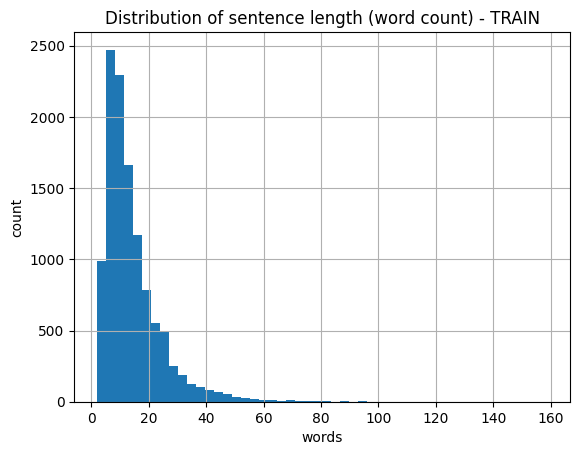

count    11426.000000
mean        14.308769
std         10.089727
min          2.000000
25%          8.000000
50%         11.000000
75%         17.000000
max        159.000000
Name: len_words, dtype: float64

In [7]:
import matplotlib.pyplot as plt

print("Sentiment distribution (train):")
display(train_df["sentiment_id"].value_counts().sort_index())
display(train_df["sentiment_id"].value_counts(normalize=True).sort_index())

print("Topic distribution (train):")
display(train_df["topic_id"].value_counts().sort_index())
display(train_df["topic_id"].value_counts(normalize=True).sort_index())

tmp = train_df.copy()
tmp["len_words"] = tmp["sentence"].astype(str).apply(lambda x: len(x.split()))
plt.figure()
tmp["len_words"].hist(bins=50)
plt.title("Distribution of sentence length (word count) - TRAIN")
plt.xlabel("words"); plt.ylabel("count")
plt.show()

tmp["len_words"].describe()

## 5) Tiền xử lý tiếng Việt (Chương 4.2)

In [8]:
import re

def remove_html(text: str) -> str:
    return re.sub(r"<.*?>", " ", text)

def remove_url(text: str) -> str:
    return re.sub(r"http\S+|www\S+", " ", text)

def normalize_spaces(text: str) -> str:
    return " ".join(str(text).split())

_EMOJI = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\u2600-\u26FF"
    "\u2700-\u27BF"
    "]+",
    flags=re.UNICODE
)

def remove_emoji(text: str) -> str:
    return _EMOJI.sub(" ", text)

ABBR = {
    "ko":"không","k":"không","kh":"không","hok":"không","k0":"không",
    "bt":"bình thường","ok":"ổn","dc":"được","đc":"được","vs":"với",
    "th":"thầy","gv":"giảng viên","sv":"sinh viên"
}
def expand_abbr(text: str) -> str:
    tokens = str(text).split()
    tokens = [ABBR.get(t.lower(), t) for t in tokens]
    return " ".join(tokens)

USE_WORD_SEGMENT = False
try:
    from underthesea import word_tokenize
    USE_WORD_SEGMENT = True
except Exception:
    USE_WORD_SEGMENT = False

def preprocess_vi(text: str, do_segment: bool = False) -> str:
    text = str(text)
    text = remove_html(text)
    text = remove_url(text)
    text = remove_emoji(text)
    text = expand_abbr(text)
    text = normalize_spaces(text)
    if do_segment and USE_WORD_SEGMENT:
        text = word_tokenize(text, format="text")
    return text

DO_SEGMENTATION = False  # PhoBERT: bạn có thể thử True để ablation

for df in [train_df, val_df, test_df]:
    df["text"] = df["sentence"].apply(lambda x: preprocess_vi(x, do_segment=DO_SEGMENTATION))

train_df[["sentence","text"]].head(5)

c:\Users\ASUS\anaconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,sentence,text
0,slide giáo trình đầy đủ .,slide giáo trình đầy đủ .
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .","nhiệt tình giảng dạy , gần gũi với sinh viên ."
2,đi học đầy đủ full điểm chuyên cần .,đi học đầy đủ full điểm chuyên cần .
3,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp dụng công nghệ thông tin và các thiết ...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...","thầy giảng bài hay , có nhiều bài tập ví dụ ng..."


## 6) One-Hot-Encoding topic

In [9]:
import numpy as np

def to_onehot_topic(topic_id, num_topics=NUM_TOPICS):
    vec = np.zeros(num_topics, dtype=np.float32)
    vec[int(topic_id)] = 1.0
    return vec

train_df["topic_vec"] = train_df["topic_id"].apply(to_onehot_topic)
val_df["topic_vec"]   = val_df["topic_id"].apply(to_onehot_topic)
test_df["topic_vec"]  = test_df["topic_id"].apply(to_onehot_topic)

train_df[["topic_id","topic_vec"]].head()

,topic_id,topic_vec
0,1,"[0.0, 1.0, 0.0, 0.0]"
1,0,"[1.0, 0.0, 0.0, 0.0]"
2,1,"[0.0, 1.0, 0.0, 0.0]"
3,0,"[1.0, 0.0, 0.0, 0.0]"
4,0,"[1.0, 0.0, 0.0, 0.0]"


## 7) Build HF Dataset

In [10]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df[["text","sentiment_id","topic_vec"]])
val_ds   = Dataset.from_pandas(val_df[["text","sentiment_id","topic_vec"]])
test_ds  = Dataset.from_pandas(test_df[["text","sentiment_id","topic_vec"]])

train_ds, val_ds, test_ds

(Dataset({
     features: ['text', 'sentiment_id', 'topic_vec'],
     num_rows: 11426
 }),
 Dataset({
     features: ['text', 'sentiment_id', 'topic_vec'],
     num_rows: 1583
 }),
 Dataset({
     features: ['text', 'sentiment_id', 'topic_vec'],
     num_rows: 3166
 }))

## 8) Tokenizer (PhoBERT)

In [11]:
from transformers import AutoTokenizer, DataCollatorWithPadding

MODEL_NAME = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

train_ds_tok = train_ds.map(tok, batched=True)
val_ds_tok   = val_ds.map(tok, batched=True)
test_ds_tok  = test_ds.map(tok, batched=True)

collator = DataCollatorWithPadding(tokenizer=tokenizer)

c:\Users\ASUS\anaconda3\envs\ml\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 3166/3166 [00:00<00:00, 17437.07 examples/s]


## 9) Mô tả Embedding (CLS) — dùng cho slide

- Encoder tạo ra `last_hidden_state` cho từng token.
- Lấy vector `CLS` làm biểu diễn câu.
- Đưa CLS qua 2 head để dự đoán sentiment và topic.

## 10) Model + Trainer

In [12]:
import torch
import torch.nn as nn
from transformers import AutoModel

class MultiTaskModel(nn.Module):
    """Shared encoder + 2 heads (sentiment softmax, topic sigmoid)."""
    def __init__(self, encoder_name: str, n_sent: int, n_topic: int, dropout=0.1, alpha=1.0):
        super().__init__()
        self.encoder_name = encoder_name
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden = self.encoder.config.hidden_size
        self.drop = nn.Dropout(dropout)

        self.sent_head = nn.Linear(hidden, n_sent)
        self.topic_head = nn.Linear(hidden, n_topic)

        self.ce = nn.CrossEntropyLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.alpha = float(alpha)

    def forward(self, input_ids=None, attention_mask=None, sentiment_labels=None, topic_labels=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        cls = self.drop(cls)

        sent_logits = self.sent_head(cls)
        topic_logits = self.topic_head(cls)

        loss = None
        if sentiment_labels is not None and topic_labels is not None:
            loss_sent = self.ce(sent_logits, sentiment_labels)
            loss_topic = self.bce(topic_logits, topic_labels)
            loss = loss_sent + self.alpha * loss_topic

        return {"loss": loss, "sent_logits": sent_logits, "topic_logits": topic_logits, "cls": cls}

In [13]:
from transformers import Trainer

class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Extract labels from inputs dict (not from BatchEncoding)
        sentiment_labels = inputs.pop("sentiment_id", None)
        topic_labels = inputs.pop("topic_vec", None)
        
        # If labels are missing, check if they're in the data dict
        if sentiment_labels is None or topic_labels is None:
            raise KeyError(f"Missing labels in inputs. Available keys: {list(inputs.keys())}")
        
        outputs = model(**inputs, sentiment_labels=sentiment_labels, topic_labels=topic_labels)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

## 11) Format torch

In [14]:
def format_torch(ds):
    keep = ["input_ids","attention_mask","sentiment_id","topic_vec"]
    drop = [c for c in ds.column_names if c not in keep]
    ds = ds.remove_columns(drop)
    ds.set_format(type="torch")
    return ds

In [15]:
train_ds2 = format_torch(train_ds_tok)
val_ds2   = format_torch(val_ds_tok)
test_ds2  = format_torch(test_ds_tok)

## 12) Train (fine-tune)

In [18]:
class MultiTaskModel(nn.Module):
    def __init__(self, encoder_name, n_sent, n_topic, dropout=0.1, alpha=1.0):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden = self.encoder.config.hidden_size

        self.drop = nn.Dropout(dropout)
        self.sent_head = nn.Linear(hidden, n_sent)
        self.topic_head = nn.Linear(hidden, n_topic)

        self.ce = nn.CrossEntropyLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.alpha = alpha

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        sentiment_id=None,   # ✅ ĐỔI TÊN
        topic_vec=None,      # ✅ ĐỔI TÊN
        **kwargs             # ✅ RẤT QUAN TRỌNG (Trainer truyền extra args)
    ):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = self.drop(outputs.last_hidden_state[:, 0])

        sent_logits = self.sent_head(cls)
        topic_logits = self.topic_head(cls)

        loss = None
        if sentiment_id is not None and topic_vec is not None:
            loss_sent = self.ce(sent_logits, sentiment_id)
            loss_topic = self.bce(topic_logits, topic_vec)
            loss = loss_sent + self.alpha * loss_topic

        return {
            "loss": loss,
            "sent_logits": sent_logits,
            "topic_logits": topic_logits
        }


In [19]:
class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        sentiment_labels = inputs.pop("sentiment_id")
        topic_labels = inputs.pop("topic_vec")

        outputs = model(
            **inputs,
            sentiment_id=sentiment_labels,
            topic_vec=topic_labels
        )

        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

    def prediction_step(
        self,
        model,
        inputs,
        prediction_loss_only,
        ignore_keys=None
    ):
        with torch.no_grad():
            loss = self.compute_loss(model, inputs)

        return (loss, None, None)


In [20]:
import os
import torch
from transformers import TrainingArguments, EarlyStoppingCallback

OUT_DIR = os.path.join(PROJECT_ROOT, "outputs", "models", "phobert_multitask")
os.makedirs(OUT_DIR, exist_ok=True)

ALPHA = 1.0  # trọng số topic loss

args = TrainingArguments(
    output_dir=OUT_DIR,
    evaluation_strategy="epoch",   # ✅ SỬA Ở ĐÂY
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.05,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_strategy="epoch",
    fp16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False
)

model = MultiTaskModel(
    MODEL_NAME,
    n_sent=NUM_SENT,
    n_topic=NUM_TOPICS,
    alpha=ALPHA
).to(DEVICE)

trainer = MultiTaskTrainer(
    model=model,
    args=args,
    train_dataset=train_ds2,
    eval_dataset=val_ds2,
    tokenizer=tokenizer,
    data_collator=collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()


                                        
  0%|          | 0/3575 [27:20<?, ?it/s]            

{'loss': 0.7748, 'grad_norm': 27.99260902404785, 'learning_rate': 8.421672555948175e-06, 'epoch': 1.0}




















































                                        

                                         
  0%|          | 0/3575 [28:18<?, ?it/s]            



{'eval_loss': 0.46453723311424255, 'eval_runtime': 57.6248, 'eval_samples_per_second': 27.471, 'eval_steps_per_second': 0.868, 'epoch': 1.0}


                                        
  0%|          | 0/3575 [53:26<?, ?it/s]             

...



















































                                          

                                         
  0%|          | 0/3575 [3:50:15<?, ?it/s]           



{'eval_loss': 0.3732507526874542, 'eval_runtime': 58.6803, 'eval_samples_per_second': 26.977, 'eval_steps_per_second': 0.852, 'epoch': 5.0}


                                          
100%|██████████| 3575/3575 [3:48:32<00:00,  3.84s/it]

{'train_runtime': 13712.6642, 'train_samples_per_second': 4.166, 'train_steps_per_second': 0.261, 'train_loss': 0.42126521183894233, 'epoch': 5.0}


TrainOutput(global_step=3575, training_loss=0.42126521183894233, metrics={'train_runtime': 13712.6642, 'train_samples_per_second': 4.166, 'train_steps_per_second': 0.261, 'train_loss': 0.42126521183894233, 'epoch': 5.0})

In [21]:
import os
import torch
from transformers import TrainingArguments, EarlyStoppingCallback

OUT_DIR = os.path.join(PROJECT_ROOT, "outputs", "models", "phobert_multitask")
os.makedirs(OUT_DIR, exist_ok=True)

args = TrainingArguments(
    output_dir=OUT_DIR,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.05,
    logging_strategy="epoch",
    fp16=torch.cuda.is_available(),
    report_to="none",

    # 🔥 QUAN TRỌNG
    load_best_model_at_end=False,   # ❌ TẮT
    remove_unused_columns=False
)

model = MultiTaskModel(
    MODEL_NAME,
    n_sent=NUM_SENT,
u    n_topic=NUM_TOPICS,
    alpha=ALPHA
).to(DEVICE)

trainer = MultiTaskTrainer(
    model=model,
    args=args,
    train_dataset=train_ds2,
    eval_dataset=val_ds2,
    tokenizer=tokenizer,
    data_collator=collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()


SyntaxError: invalid syntax. Perhaps you forgot a comma? (2894337763.py, line 30)

In [ ]:
import os
import torch
from transformers import TrainingArguments, EarlyStoppingCallback











OUT_DIR = os.path.join(PROJECT_ROOT, "outputs", "models", "phobert_multitask")
os.makedirs(OUT_DIR, exist_ok=True)

ALPHA = 1.0  # trọng số topic loss

# Cell 37
args = TrainingArguments(
    output_dir=OUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.05,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_strategy="epoch",
    fp16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False  # <--- THÊM DÒNG NÀY
)

model = MultiTaskModel(
    MODEL_NAME,
    n_sent=NUM_SENT,
    n_topic=NUM_TOPICS,
    alpha=ALPHA
).to(DEVICE)

trainer = MultiTaskTrainer(
    model=model,
    args=args,
    train_dataset=train_ds2,
    eval_dataset=val_ds2,
    tokenizer=tokenizer,
    data_collator=collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()


SyntaxError: invalid decimal literal (3480944427.py, line 15)

## 13) Evaluate TEST + lưu outputs

In [22]:
import numpy as np, torch
from transformers import DataCollatorWithPadding

def predict_logits(model, ds, tokenizer, batch_size=32, device="cpu"):
    model.eval()
    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=collator)

    sent_logits_all, topic_logits_all = [], []
    y_sent_all, y_topic_all = [], []

    for batch in loader:
        y_sent = batch.pop("sentiment_id")
        y_topic = batch.pop("topic_vec")

        batch = {k:v.to(device) for k,v in batch.items()}
        with torch.no_grad():
            out = model(**batch)
        sent_logits_all.append(out["sent_logits"].detach().cpu().numpy())
        topic_logits_all.append(out["topic_logits"].detach().cpu().numpy())
        y_sent_all.append(y_sent.detach().cpu().numpy())
        y_topic_all.append(y_topic.detach().cpu().numpy())

    return (
        np.vstack(sent_logits_all),
        np.vstack(topic_logits_all),
        np.concatenate(y_sent_all),
        np.vstack(y_topic_all),
    )

In [24]:
import numpy as np

# ===== SIGMOID =====
def sigmoid(x):
    """
    x: numpy array hoặc torch tensor
    return: xác suất sau sigmoid
    """
    if hasattr(x, "detach"):  # torch tensor
        x = x.detach().cpu().numpy()
    return 1 / (1 + np.exp(-x))


# ===== APPLY THRESHOLD FOR MULTI-LABEL =====
def apply_threshold(prob, th=0.5, fallback="max"):
    """
    prob: (N, num_topics) – xác suất sau sigmoid
    th: threshold
    fallback:
        - "max": nếu không nhãn nào > th → chọn nhãn có prob lớn nhất
        - None: giữ toàn 0
    """
    y_pred = (prob >= th).astype(int)

    if fallback == "max":
        for i in range(len(y_pred)):
            if y_pred[i].sum() == 0:
                y_pred[i, prob[i].argmax()] = 1

    return y_pred


In [25]:
sent_logits, topic_logits, y_sent_true, y_topic_true = predict_logits(model, test_ds2, tokenizer, batch_size=32, device=DEVICE)
y_sent_pred = sent_logits.argmax(-1)

topic_prob = sigmoid(topic_logits)
DEFAULT_TH = 0.35
y_topic_pred = apply_threshold(topic_prob, th=DEFAULT_TH, fallback="max")

In [26]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np, os

def eval_sentiment(y_true, y_pred, out_prefix: str, figures_dir: str):
    acc = accuracy_score(y_true, y_pred)
    _, _, f1_ma, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    _, _, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    print("=== SENTIMENT METRICS ===")
    print({"accuracy": acc, "f1_macro": f1_ma, "f1_weighted": f1_w, "kappa": kappa, "mcc": mcc})
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=[SENT_ID2LABEL[i] for i in range(NUM_SENT)], digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=[SENT_ID2LABEL[i] for i in range(NUM_SENT)],
                yticklabels=[SENT_ID2LABEL[i] for i in range(NUM_SENT)])
    plt.title(f"{out_prefix} - Sentiment Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    fig_path = os.path.join(figures_dir, f"{out_prefix}_sent_cm.png")
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    return {"accuracy": float(acc), "f1_macro": float(f1_ma), "f1_weighted": float(f1_w), "kappa": float(kappa), "mcc": float(mcc), "cm_path": fig_path}

=== SENTIMENT METRICS ===
{'accuracy': 0.930511686670878, 'f1_macro': 0.7910731879969806, 'f1_weighted': 0.9254463744645506, 'kappa': 0.8708540999169336, 'mcc': 0.8715264384768471}

Classification report:
              precision    recall  f1-score   support

    negative     0.9384    0.9617    0.9499      1409
     neutral     0.6300    0.3772    0.4719       167
    positive     0.9420    0.9610    0.9514      1590

    accuracy                         0.9305      3166
   macro avg     0.8368    0.7666    0.7911      3166
weighted avg     0.9239    0.9305    0.9254      3166



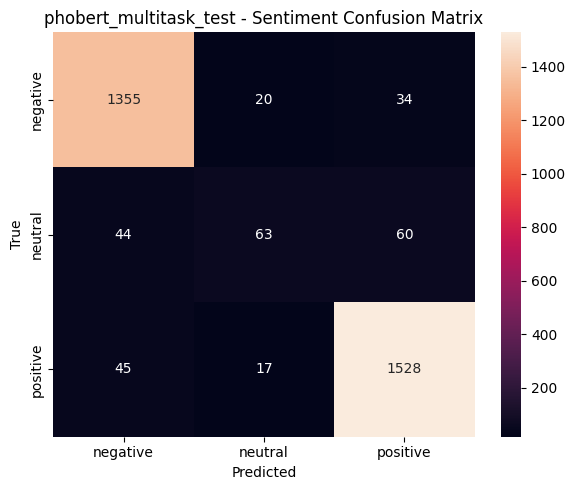

In [27]:
sent_metrics = eval_sentiment(y_sent_true, y_sent_pred, out_prefix="phobert_multitask_test", figures_dir=PATHS["figures"])

In [28]:
from sklearn.metrics import f1_score, hamming_loss, jaccard_score, classification_report, ConfusionMatrixDisplay
import numpy as np, os, matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def apply_threshold(prob, th=0.35, per_label_th=None, fallback="max"):
    if per_label_th is None:
        pred = (prob >= th).astype(int)
    else:
        per = np.asarray(per_label_th).reshape(1, -1)
        pred = (prob >= per).astype(int)

    if fallback == "max":
        for i in range(len(pred)):
            if pred[i].sum() == 0:
                pred[i, int(prob[i].argmax())] = 1
    return pred

def eval_topics(y_true, y_pred, out_prefix: str, figures_dir: str):
    f1_micro  = f1_score(y_true, y_pred, average="micro", zero_division=0)
    f1_macro  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_samples = f1_score(y_true, y_pred, average="samples", zero_division=0)
    ham = hamming_loss(y_true, y_pred)
    jac = jaccard_score(y_true, y_pred, average="samples", zero_division=0)

    print("=== TOPIC MULTI-LABEL METRICS ===")
    print({"f1_micro": f1_micro, "f1_macro": f1_macro, "f1_samples": f1_samples, "hamming": ham, "jaccard_samples": jac})

    topic_names = [TOPIC_ID2LABEL[i] for i in range(NUM_TOPICS)]
    print("\nPer-label report:")
    print(classification_report(y_true, y_pred, target_names=topic_names, digits=4, zero_division=0))

    for j, name in enumerate(topic_names):
        y_t = y_true[:, j]
        y_p = y_pred[:, j]
        ConfusionMatrixDisplay.from_predictions(y_t, y_p, labels=[0,1], cmap="Blues")
        plt.title(f"{out_prefix} - OvR Confusion (topic={name})")
        plt.tight_layout()
        fig_path = os.path.join(figures_dir, f"{out_prefix}_topic_{name}_ovr_cm.png")
        plt.savefig(fig_path, dpi=200, bbox_inches="tight")
        plt.show()

    return {"f1_micro": float(f1_micro), "f1_macro": float(f1_macro), "f1_samples": float(f1_samples), "hamming": float(ham), "jaccard_samples": float(jac)}

=== TOPIC MULTI-LABEL METRICS ===
{'f1_micro': 0.881733746130031, 'f1_macro': 0.7660842843761462, 'f1_samples': 0.8872394188250158, 'hamming': 0.06032849020846494, 'jaccard_samples': 0.8810802274162982}

Per-label report:
                  precision    recall  f1-score   support

        lecturer     0.9252    0.9502    0.9375      2290
training_program     0.6964    0.8339    0.7589       572
        facility     0.8867    0.9172    0.9017       145
          others     0.5794    0.3899    0.4662       159

       micro avg     0.8646    0.8996    0.8817      3166
       macro avg     0.7719    0.7728    0.7661      3166
    weighted avg     0.8647    0.8996    0.8800      3166
     samples avg     0.8811    0.8996    0.8872      3166



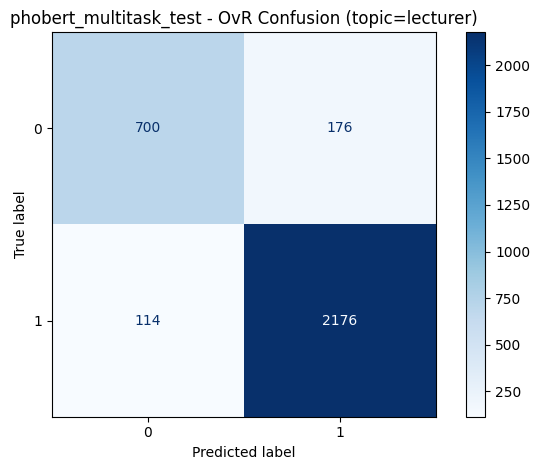

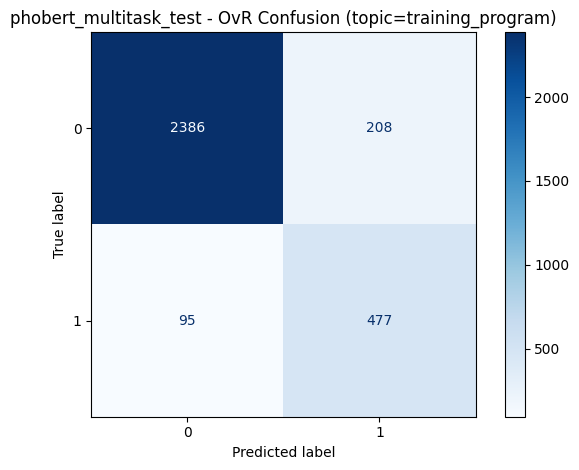

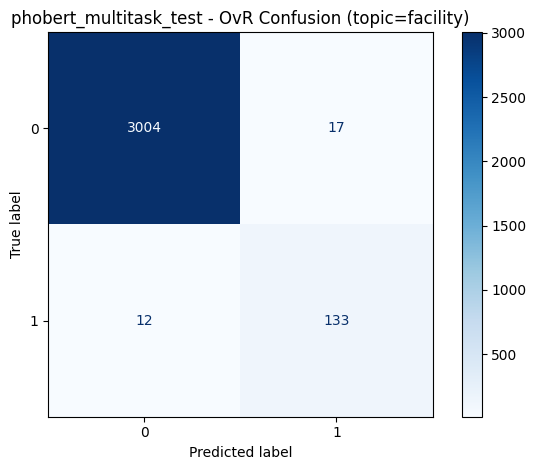

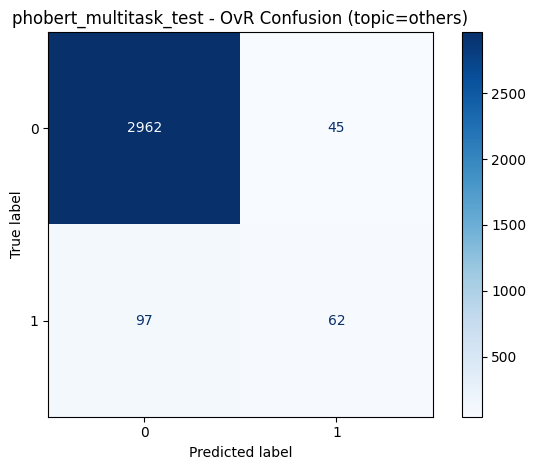

In [29]:
topic_metrics = eval_topics(y_topic_true, y_topic_pred, out_prefix="phobert_multitask_test", figures_dir=PATHS["figures"])

## 14) Save metrics & predictions

In [30]:
import json, pandas as pd, os

metrics = {"sentiment": sent_metrics, "topic": {"threshold": DEFAULT_TH, **topic_metrics}}
metrics_path = os.path.join(PATHS["metrics"], "phobert_multitask_test_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

pred_df = test_df.copy()
pred_df["sent_pred"] = y_sent_pred
pred_df["sent_pred_label"] = pred_df["sent_pred"].map(SENT_ID2LABEL)

for j in range(NUM_TOPICS):
    pred_df[f"topic_prob_{TOPIC_ID2LABEL[j]}"] = topic_prob[:, j]

pred_df.to_csv(os.path.join(PATHS["preds"], "phobert_multitask_test_predictions.csv"), index=False, encoding="utf-8-sig")
print("Saved:", metrics_path)

Saved: c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\outputs\metrics\phobert_multitask_test_metrics.json


## 15) Save model bundle

In [31]:
import os, json, torch

def save_bundle(save_dir, model, tokenizer, extra: dict):
    os.makedirs(save_dir, exist_ok=True)
    tokenizer.save_pretrained(save_dir)
    torch.save(model.state_dict(), os.path.join(save_dir, "pytorch_model.bin"))
    with open(os.path.join(save_dir, "label_maps.json"), "w", encoding="utf-8") as f:
        json.dump({"sentiment": SENT_ID2LABEL, "topic": TOPIC_ID2LABEL}, f, ensure_ascii=False, indent=2)
    with open(os.path.join(save_dir, "bundle_config.json"), "w", encoding="utf-8") as f:
        json.dump(extra, f, ensure_ascii=False, indent=2)
    print("Saved bundle to:", save_dir)

In [32]:
import datetime, os

SAVE_DIR = os.path.join(PROJECT_ROOT, "outputs", "models", "phobert_multitask", "final_model")
save_bundle(
    SAVE_DIR,
    model=model,
    tokenizer=tokenizer,
    extra={
        "encoder_name": MODEL_NAME,
        "alpha": ALPHA,
        "default_threshold": DEFAULT_TH,
        "max_length": 256,
        "do_segmentation": DO_SEGMENTATION,
        "created_at": str(datetime.datetime.now())
    }
)

Saved bundle to: c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\outputs\models\phobert_multitask\final_model


## 16) One-sample walkthrough (mục 4.4)

In [34]:
import torch, numpy as np

def walkthrough_one_sample(
    text: str,
    tokenizer,
    model,
    max_len=64,
    threshold=0.35,
    per_label_th=None
):
    print("=== 1) Raw text ===")
    print(text)

    print("\n=== 2) Preprocessed text ===")
    text2 = preprocess_vi(text, do_segment=DO_SEGMENTATION)
    print(text2)

    print("\n=== 3) Tokenize ===")
    enc = tokenizer(
        text2,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    input_ids = enc["input_ids"][0].tolist()
    attn = enc["attention_mask"][0].tolist()

    print("input_ids[:32] =", input_ids[:32], "...")
    print("attention_mask[:32] =", attn[:32], "...")
    print("Decoded tokens[:24] =", tokenizer.convert_ids_to_tokens(input_ids[:24]))

    print("\n=== 4) Encoder output & CLS embedding ===")
    model.eval()
    with torch.no_grad():
        # 👉 chạy encoder trực tiếp
        enc_out = model.encoder(
            input_ids=enc["input_ids"].to(DEVICE),
            attention_mask=enc["attention_mask"].to(DEVICE)
        )
        cls = enc_out.last_hidden_state[:, 0, :].cpu()

        # 👉 chạy head
        out = model(
            input_ids=enc["input_ids"].to(DEVICE),
            attention_mask=enc["attention_mask"].to(DEVICE)
        )

    print("CLS shape =", tuple(cls.shape))
    print("CLS first 10 dims =", cls[0, :10].numpy())

    print("\n=== 5) Sentiment head (softmax) ===")
    sent_logits = out["sent_logits"].cpu().numpy()[0]
    sent_prob = np.exp(sent_logits) / np.exp(sent_logits).sum()
    sent_id = int(sent_prob.argmax())

    print("sent_prob =", np.round(sent_prob, 4))
    print("pred_sent =", SENT_ID2LABEL[sent_id])

    print("\n=== 6) Topic head (sigmoid + threshold) ===")
    topic_logits = out["topic_logits"].cpu().numpy()[0]
    topic_prob = 1 / (1 + np.exp(-topic_logits))

    if per_label_th is None:
        y_pred = (topic_prob >= threshold).astype(int)
        th_used = [threshold] * NUM_TOPICS
    else:
        th_used = list(per_label_th)
        y_pred = (topic_prob >= np.array(per_label_th)).astype(int)

    if y_pred.sum() == 0:
        y_pred[int(topic_prob.argmax())] = 1

    topics = [TOPIC_ID2LABEL[i] for i, v in enumerate(y_pred) if v == 1]

    print("topic_prob  =", np.round(topic_prob, 4))
    print("thresholds  =", np.round(np.array(th_used), 3))
    print("pred_topics =", topics)

    return {
        "sentiment": SENT_ID2LABEL[sent_id],
        "topics": topics,
        "topic_prob": topic_prob
    }


In [35]:
demo_text = "Phòng học nóng quá, máy lạnh hư mà thầy giảng hơi nhanh."
_ = walkthrough_one_sample(
    demo_text,
    tokenizer,
    model,
    max_len=64,
    threshold=DEFAULT_TH
)


=== 1) Raw text ===
Phòng học nóng quá, máy lạnh hư mà thầy giảng hơi nhanh.

=== 2) Preprocessed text ===
Phòng học nóng quá, máy lạnh hư mà thầy giảng hơi nhanh.

=== 3) Tokenize ===
input_ids[:32] = [0, 1119, 222, 898, 20027, 4, 558, 1310, 6007, 64, 1249, 5415, 1329, 37361, 18109, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...
attention_mask[:32] = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...
Decoded tokens[:24] = ['<s>', 'Phòng', 'học', 'nóng', 'quá@@', ',', 'máy', 'lạnh', 'hư', 'mà', 'thầy', 'giảng', 'hơi', 'nha@@', 'nh.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

=== 4) Encoder output & CLS embedding ===
CLS shape = (1, 768)
CLS first 10 dims = [-0.25640368  0.32151514  0.07331195  0.0726586  -0.28230426  0.22680895
  0.81370765 -0.65350723  0.34339306 -0.24170952]

=== 5) Sentiment head (softmax) ===
sent_prob = [0.9957 0.0023 0.0021]
pred_sent = negative

=== 6) Topic head (si

In [33]:
import torch, numpy as np

def walkthrough_one_sample(text: str, tokenizer, model, max_len=64, threshold=0.35, per_label_th=None):
    print("=== 1) Raw text ===")
    print(text)

    print("\n=== 2) Preprocessed text ===")
    text2 = preprocess_vi(text, do_segment=DO_SEGMENTATION)
    print(text2)

    print("\n=== 3) Tokenize (input_ids / attention_mask) ===")
    enc = tokenizer(text2, truncation=True, padding="max_length", max_length=max_len, return_tensors="pt")
    input_ids = enc["input_ids"][0].tolist()
    attn = enc["attention_mask"][0].tolist()
    print("input_ids[:32] =", input_ids[:32], "...")
    print("attention_mask[:32] =", attn[:32], "...")
    print("Decoded tokens[:24] =", tokenizer.convert_ids_to_tokens(input_ids[:24]))

    print("\n=== 4) Encoder output & CLS embedding ===")
    model.eval()
    with torch.no_grad():
        out = model(input_ids=enc["input_ids"].to(DEVICE), attention_mask=enc["attention_mask"].to(DEVICE))
    cls = out["cls"].detach().cpu()
    print("CLS shape =", tuple(cls.shape))
    print("CLS first 10 dims =", cls[0, :10].numpy())

    print("\n=== 5) Sentiment head (softmax) ===")
    sent_logits = out["sent_logits"].detach().cpu().numpy()[0]
    sent_prob = np.exp(sent_logits) / np.exp(sent_logits).sum()
    sent_id = int(sent_prob.argmax())
    print("sent_prob   =", np.round(sent_prob, 4))
    print("pred_sent   =", SENT_ID2LABEL[sent_id])

    print("\n=== 6) Topic head (sigmoid) + threshold ===")
    topic_logits = out["topic_logits"].detach().cpu().numpy()[0]
    topic_prob = 1 / (1 + np.exp(-topic_logits))
    if per_label_th is None:
        y_pred = (topic_prob >= threshold).astype(int)
        th_used = [threshold]*NUM_TOPICS
    else:
        th_used = list(per_label_th)
        y_pred = (topic_prob >= np.array(per_label_th)).astype(int)

    if y_pred.sum() == 0:
        y_pred[int(topic_prob.argmax())] = 1

    topics = [TOPIC_ID2LABEL[i] for i,v in enumerate(y_pred) if v==1]
    print("topic_prob   =", np.round(topic_prob, 4))
    print("thresholds   =", np.round(np.array(th_used), 3))
    print("pred_topics  =", topics)

    return {"sentiment": SENT_ID2LABEL[sent_id], "topics": topics, "topic_prob": topic_prob}

demo_text = "Phòng học nóng quá, máy lạnh hư mà thầy giảng hơi nhanh."
_ = walkthrough_one_sample(demo_text, tokenizer, model, max_len=64, threshold=DEFAULT_TH)

=== 1) Raw text ===
Phòng học nóng quá, máy lạnh hư mà thầy giảng hơi nhanh.

=== 2) Preprocessed text ===
Phòng học nóng quá, máy lạnh hư mà thầy giảng hơi nhanh.

=== 3) Tokenize (input_ids / attention_mask) ===
input_ids[:32] = [0, 1119, 222, 898, 20027, 4, 558, 1310, 6007, 64, 1249, 5415, 1329, 37361, 18109, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...
attention_mask[:32] = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...
Decoded tokens[:24] = ['<s>', 'Phòng', 'học', 'nóng', 'quá@@', ',', 'máy', 'lạnh', 'hư', 'mà', 'thầy', 'giảng', 'hơi', 'nha@@', 'nh.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

=== 4) Encoder output & CLS embedding ===


KeyError: 'cls'

## 17) Error analysis exporter (mục 4.8)

In [36]:
import numpy as np, pandas as pd, os

def build_error_tables(df_ref, y_sent_true, y_sent_pred, y_topic_true, topic_prob, y_topic_pred, out_prefix: str, preds_dir: str, top_k=30):
    out_dir = preds_dir
    os.makedirs(out_dir, exist_ok=True)

    sent_err_mask = (y_sent_true != y_sent_pred)
    sent_err = df_ref.loc[sent_err_mask, ["sentence","sentiment_id","topic_id"]].copy()
    sent_err["sent_true_label"] = pd.Series(y_sent_true[sent_err_mask]).map(SENT_ID2LABEL).values
    sent_err["sent_pred_label"] = pd.Series(y_sent_pred[sent_err_mask]).map(SENT_ID2LABEL).values
    sent_err_path = os.path.join(out_dir, f"{out_prefix}_error_sentiment.csv")
    sent_err.head(top_k).to_csv(sent_err_path, index=False, encoding="utf-8-sig")

    topic_err_mask = (y_topic_true != y_topic_pred).any(axis=1)
    topic_err = df_ref.loc[topic_err_mask, ["sentence","sentiment_id","topic_id"]].copy()

    def vec_to_labels(vec):
        idx = np.where(vec==1)[0].tolist()
        return [TOPIC_ID2LABEL[i] for i in idx]

    topic_err["topic_true_labels"] = [vec_to_labels(v) for v in y_topic_true[topic_err_mask]]
    topic_err["topic_pred_labels"] = [vec_to_labels(v) for v in y_topic_pred[topic_err_mask]]

    probs = topic_prob[topic_err_mask]
    for j in range(NUM_TOPICS):
        topic_err[f"prob_{TOPIC_ID2LABEL[j]}"] = probs[:, j]

    topic_err_path = os.path.join(out_dir, f"{out_prefix}_error_topic.csv")
    topic_err.head(top_k).to_csv(topic_err_path, index=False, encoding="utf-8-sig")

    print("Saved:", sent_err_path)
    print("Saved:", topic_err_path)
    return sent_err_path, topic_err_path

In [37]:
_ = build_error_tables(
    df_ref=test_df,
    y_sent_true=y_sent_true,
    y_sent_pred=y_sent_pred,
    y_topic_true=y_topic_true,
    topic_prob=topic_prob,
    y_topic_pred=y_topic_pred,
    out_prefix="phobert_multitask_test",
    preds_dir=PATHS["preds"],
    top_k=30
)

Saved: c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\outputs\output_data\phobert_multitask_test_error_sentiment.csv
Saved: c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\outputs\output_data\phobert_multitask_test_error_topic.csv


## 18) Demo predict

In [38]:
def predict_one(text, threshold=DEFAULT_TH):
    text2 = preprocess_vi(text, do_segment=DO_SEGMENTATION)
    enc = tokenizer(text2, return_tensors="pt", truncation=True, max_length=256).to(DEVICE)

    model.eval()
    with torch.no_grad():
        out = model(**enc)

    sent_id = int(out["sent_logits"].argmax(-1).item())
    sent_label = SENT_ID2LABEL[sent_id]

    prob = torch.sigmoid(out["topic_logits"]).detach().cpu().numpy()[0]
    pred = apply_threshold(prob.reshape(1,-1), th=threshold, fallback="max")[0]
    topics = [TOPIC_ID2LABEL[i] for i,v in enumerate(pred) if v==1]
    return {"sentiment": sent_label, "topics": topics, "topic_prob": prob}

predict_one("Thầy giảng dễ hiểu nhưng phòng học nóng quá.", threshold=DEFAULT_TH)

{'sentiment': 'negative',
 'topics': ['lecturer'],
 'topic_prob': array([0.88500124, 0.02936109, 0.10803252, 0.03355116], dtype=float32)}